In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel("Dataset for Data Analytics.xlsx")
print(df.shape)
print(df.head())
print(df.info())

(1200, 14)
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2  

In [2]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [3]:
missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [4]:
df.dtypes

,0
OrderID,object
Date,datetime64[ns]
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


In [5]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [6]:
df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')

In [7]:
numeric_cols = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, len(outliers))

Quantity 0
UnitPrice 0
ItemsInCart 0
TotalPrice 8


In [8]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.clip(df[col], lower, upper)

In [9]:
df['OrderMonth'] = df['Date'].dt.month

In [10]:
df['OrderYear'] = df['Date'].dt.year

In [11]:
df['CouponUsed'] = np.where(
    df['CouponCode'] == 'NoCoupon',
    0,
    1
)

In [12]:
df['AvgItemPrice'] = (
    df['TotalPrice'] / df['Quantity']
)

In [13]:
df['CartUtilization'] = (
    df['Quantity'] / df['ItemsInCart']
)

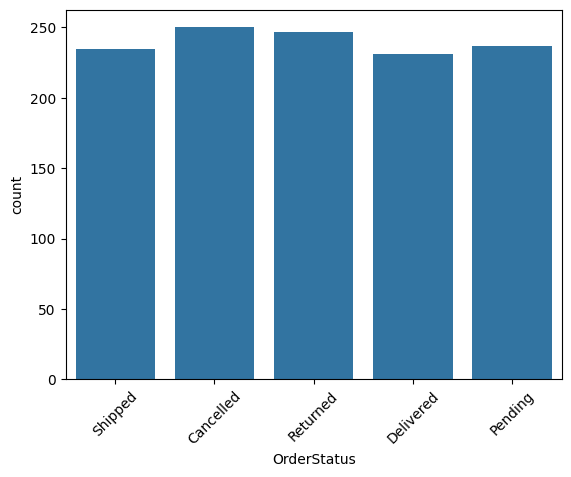

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='OrderStatus', data=df)
plt.xticks(rotation=45)
plt.show()

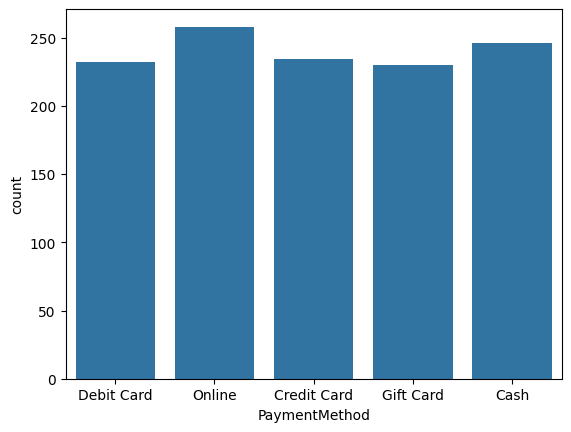

In [15]:
sns.countplot(x='PaymentMethod', data=df)
plt.show()

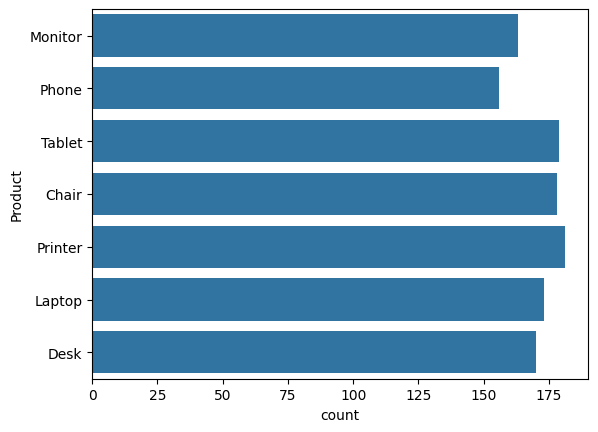

In [16]:
sns.countplot(y='Product', data=df)
plt.show()

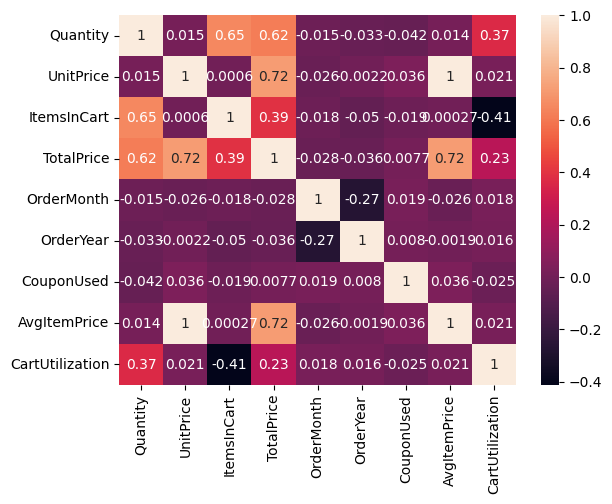

In [17]:
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True
)
plt.show()